In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
import sklearn
import scipy
import numpy as np
import sceleto2 as scl
import pickle
import glob
import os
import scrublet as scr
import matplotlib.pyplot as plt


sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, dpi_save=300, figsize=(5,5))
sc.settings.figdir = "./figures"
sc.settings.autosave = False
random_seed = 0

from datetime import date
TODAY = date.today()
print(TODAY)

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-13


In [2]:
dataset = 'pappalardo_nonneuronal'

# 1. QC

In [3]:
#adata = sc.read_h5ad("/home/neuro_demo_research/repo/epilepsy_microglia_repo/notebooks/epilepsy_microglia/data/processed/galvao/galvao.h5ad")
adata = sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}.h5ad")
adata

AnnData object with n_obs × n_vars = 6000 × 33538
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'fcd_class', 'fcd_subtype', 'mtoropathy_status', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'disease_status', 'diagnosis_raw', 'diagnosis_harmonized', 'brain_region_raw', 'lesion_position', 'control_type', 'sample_source'

In [ ]:
# check if total and nonneuronal datasets have the same cells
tdata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/pappalardo_total/pappalardo_total.h5ad")

False

In [5]:
# basic counts
print(f"Non-neuronal: {adata.n_obs:,}")
print(f"Total:        {tdata.n_obs:,}")

# overlapping cell barcodes
overlap = adata.obs_names.intersection(tdata.obs_names)

print(f"\nOverlap: {len(overlap):,}")
print(f"% of non-neuronal found in total: {len(overlap) / adata.n_obs * 100:.2f}%")
print(f"% of total found in non-neuronal: {len(overlap) / tdata.n_obs * 100:.2f}%")

# cells unique to each dataset
nonneuronal_only = adata.obs_names.difference(tdata.obs_names)
total_only = tdata.obs_names.difference(adata.obs_names)

print(f"\nNon-neuronal only: {len(nonneuronal_only):,}")
print(f"Total only:        {len(total_only):,}")

Non-neuronal: 6,000
Total:        17,664

Overlap: 0
% of non-neuronal found in total: 0.00%
% of total found in non-neuronal: 0.00%

Non-neuronal only: 6,000
Total only:        17,664


In [6]:
len(adata.obs_names.intersection(tdata.obs_names))

0

In [7]:
del tdata

In [8]:
adata.var

""
MIR1302-2HG
FAM138A
OR4F5
AL627309.1
AL627309.3
...
AC233755.2
AC233755.1
AC240274.1
AC213203.1


In [9]:
adata.obs['sample_id'].value_counts()

sample_id
B01_NeuN_negative_nuclei     2000
HC14_NeuN_negative_nuclei    2000
HC35_NeuN_negative_nuclei    2000
Name: count, dtype: int64

In [10]:
adata.obs['donor_id'].value_counts()

donor_id
Donor1_B01     2000
Donor2_HC14    2000
Donor3_HC35    2000
Name: count, dtype: int64

In [11]:
adata.var_names_make_unique()

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.upper().str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.upper().str.startswith(
    ("HBA", "HBB", "HBD", "HBE", "HBG", "HBM", "HBQ", "HBZ")
)

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)

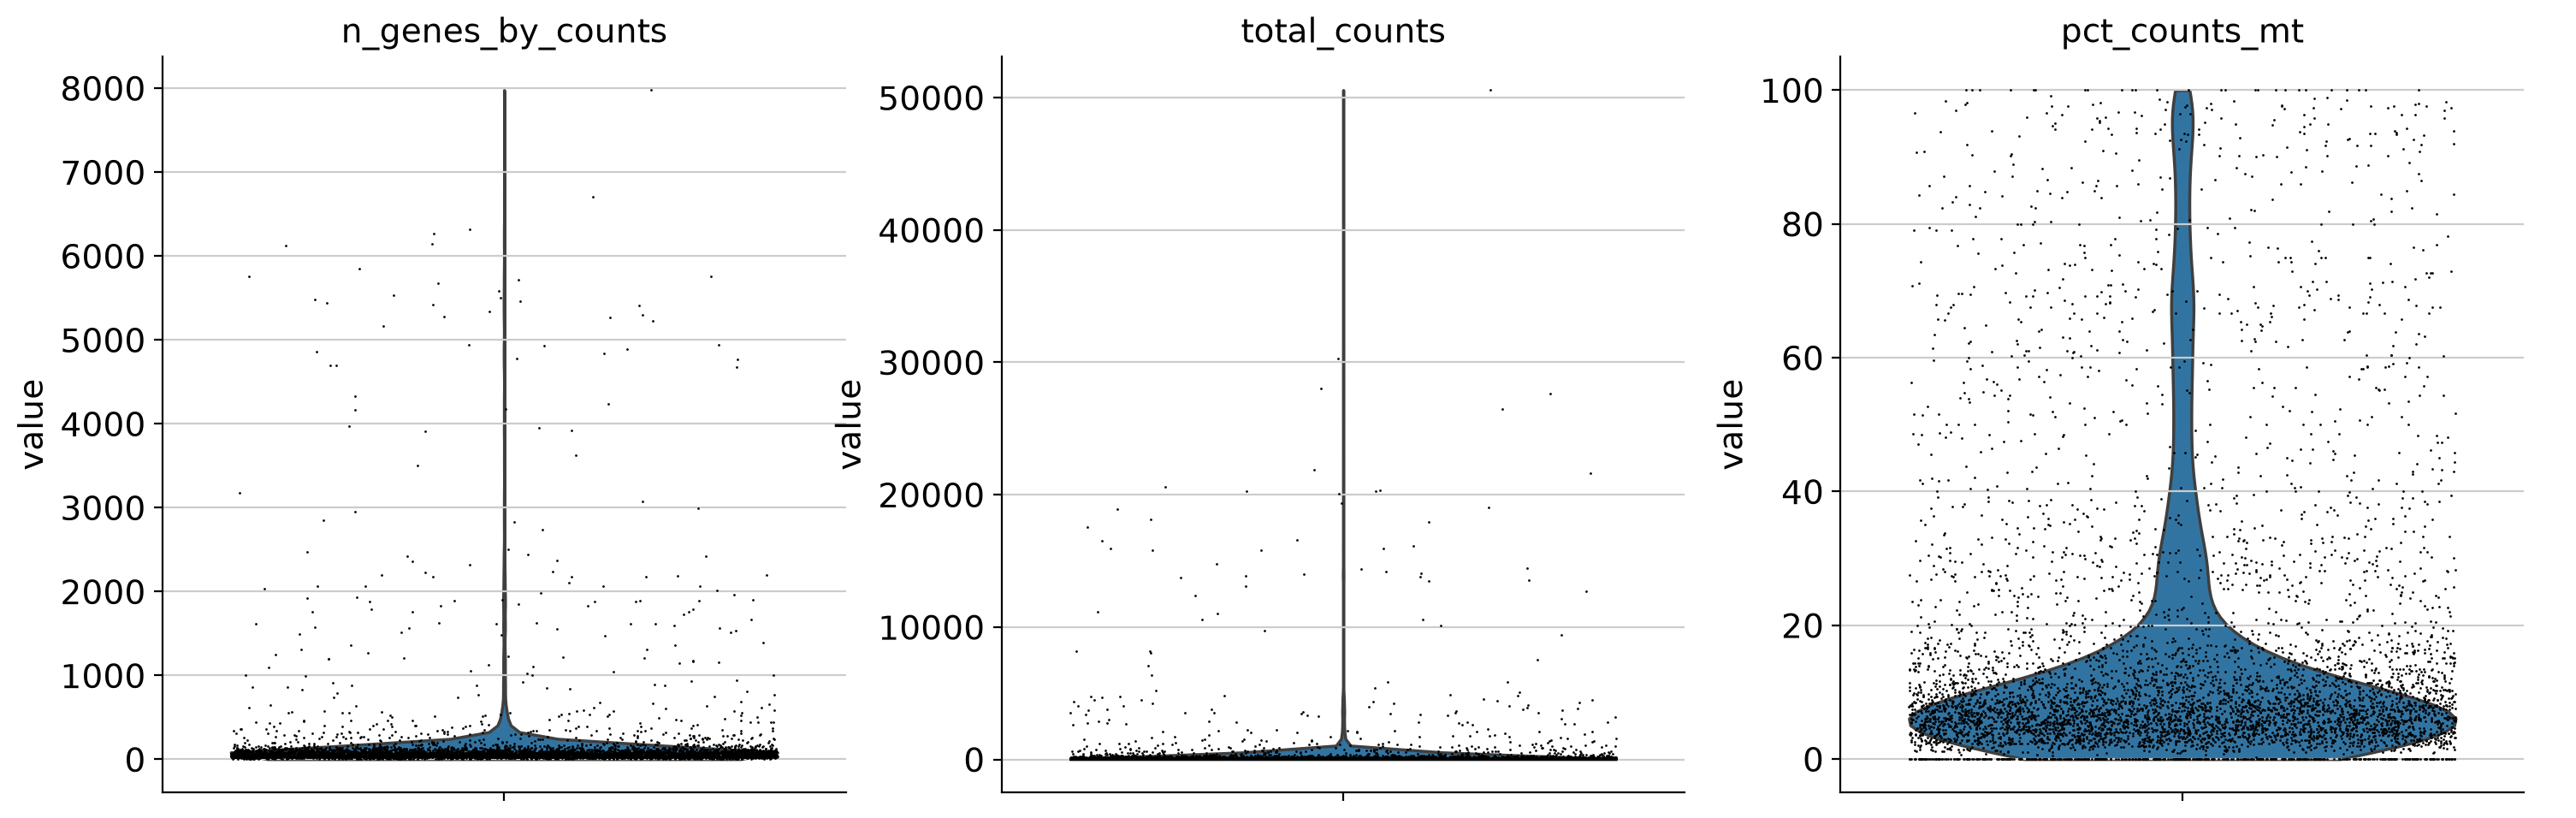

In [12]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

,sample_id,donor_id,total_counts,n_genes_by_counts
AAACCCAAGACGGATC-1-GSM4760617,B01_NeuN_negative_nuclei,Donor1_B01,86.0,47
AAACCCAAGTGCAACG-1-GSM4760617,B01_NeuN_negative_nuclei,Donor1_B01,68.0,55
AAACCCAAGTTAGTGA-1-GSM4760617,B01_NeuN_negative_nuclei,Donor1_B01,66.0,60
AAACCCAGTACGGTTT-1-GSM4760617,B01_NeuN_negative_nuclei,Donor1_B01,77.0,69
AAACCCATCGGTAGAG-1-GSM4760617,B01_NeuN_negative_nuclei,Donor1_B01,110.0,95


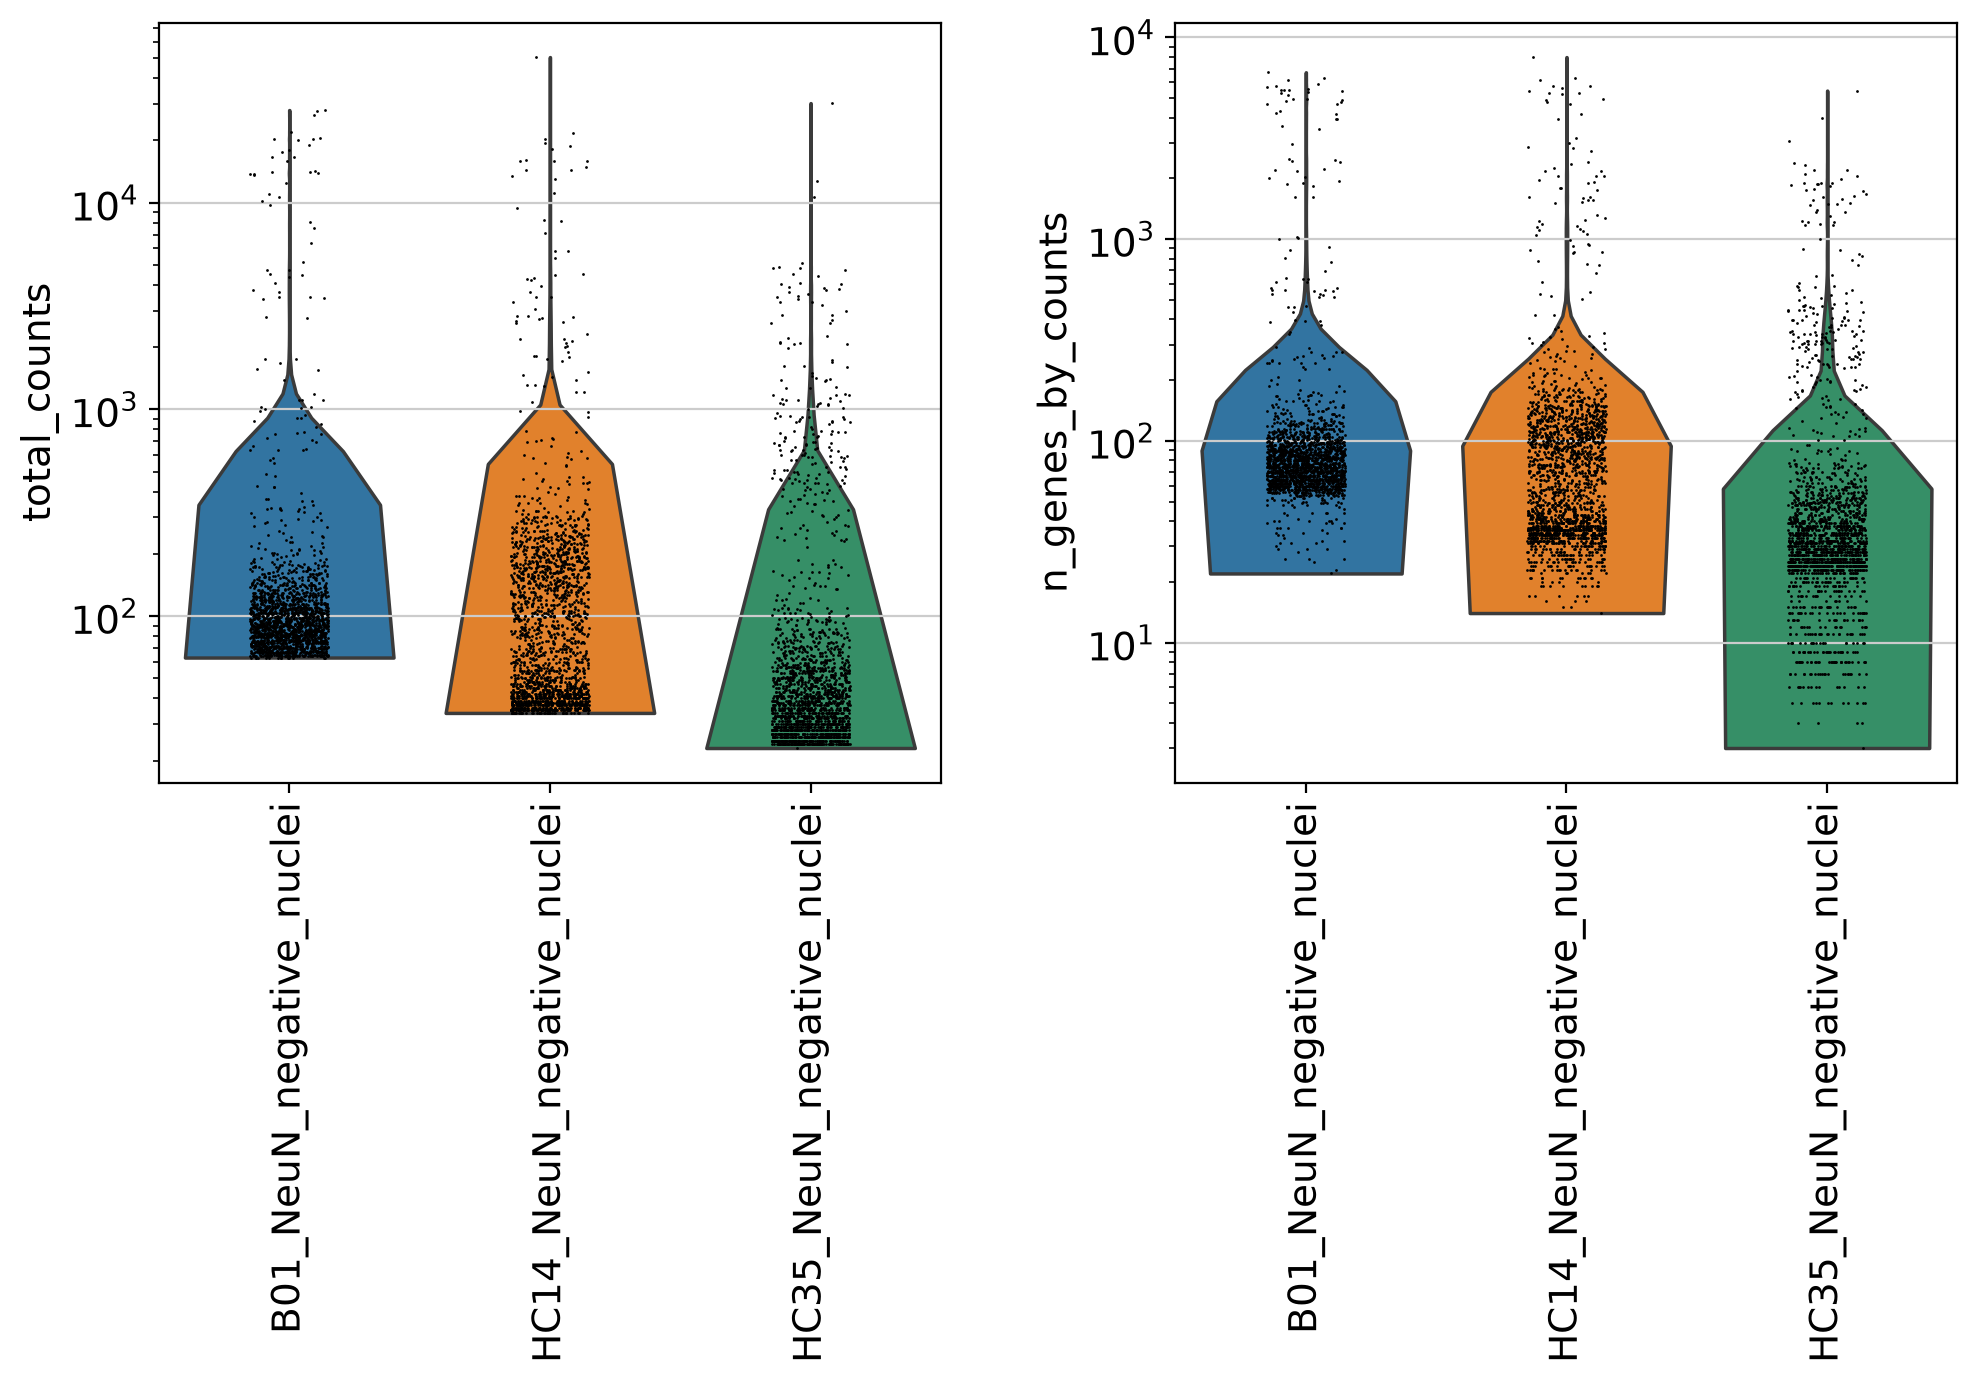

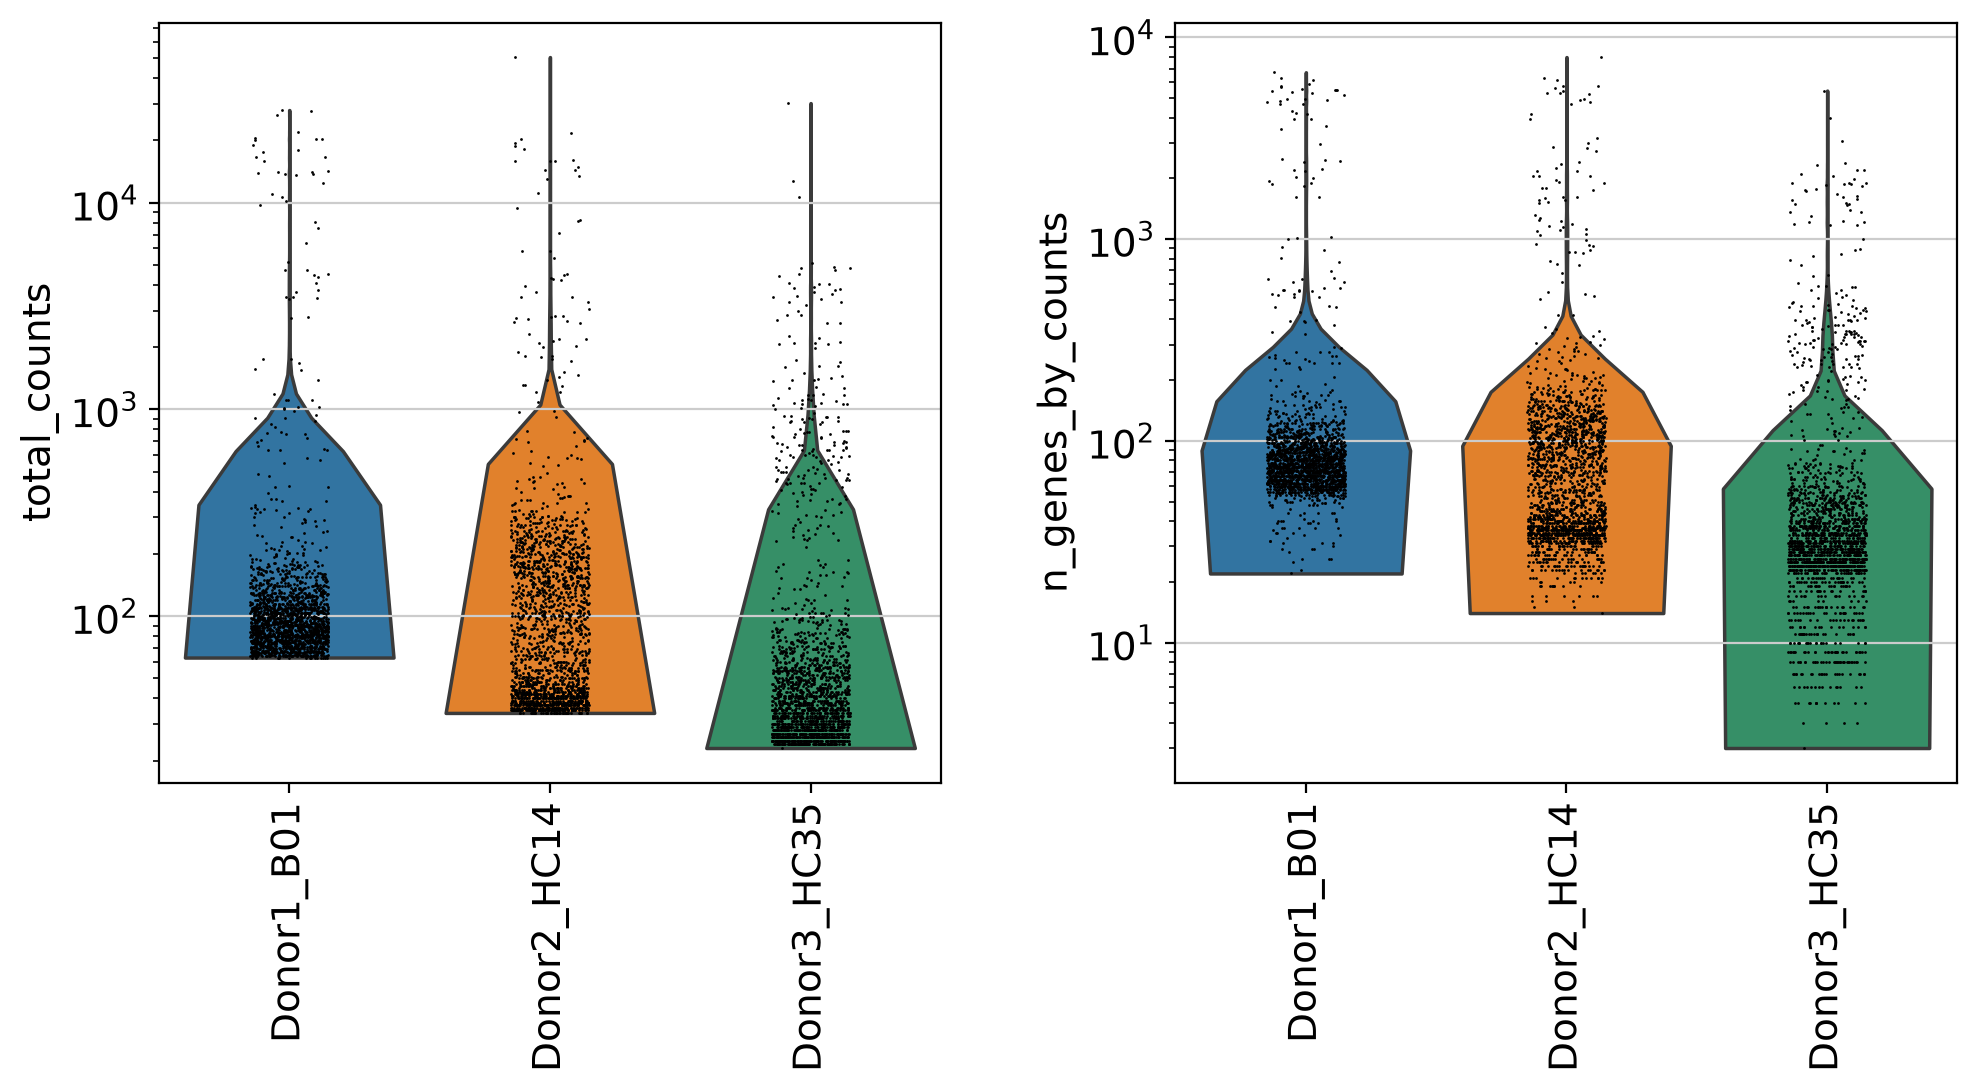

In [13]:
# check donor/sample-level qc metrics

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Use the raw-count layer if present; otherwise use adata.X.
count_layer = "counts" if "counts" in adata.layers else None

sc.pp.calculate_qc_metrics(
    adata,
    layer=count_layer,
    inplace=True,
    log1p=False,
)

# Confirm these exist before plotting.
display(
    adata.obs[
        ["sample_id", "donor_id", "total_counts", "n_genes_by_counts"]
    ].head()
)

for groupby in ["sample_id", "donor_id"]:
    if groupby not in adata.obs.columns:
        print(f"Skipping {groupby}: column not found.")
        continue

    sc.pl.violin(
        adata,
        keys=["total_counts", "n_genes_by_counts"],
        groupby=groupby,
        layer=count_layer,
        log=True,          # easier to see the low-count nuclear tail
        jitter=0.15,
        rotation=90,
        multi_panel=True,
        show=True,
    )

In [14]:
cutoffs = pd.DataFrame(
    {
        "counts≥500": adata.obs["total_counts"] >= 500,
        "counts≥1000": adata.obs["total_counts"] >= 1000,
        "counts≥2000": adata.obs["total_counts"] >= 2000,
        "genes≥300": adata.obs["n_genes_by_counts"] >= 250,
        "genes≥500": adata.obs["n_genes_by_counts"] >= 500,
    },
    index=adata.obs_names,
)

retention_by_sample = (
    cutoffs
    .join(adata.obs["sample_id"])
    .groupby("sample_id", observed=True)
    .mean()
    .mul(100)
    .round(1)
)

display(retention_by_sample)

,counts≥500,counts≥1000,counts≥2000,genes≥300,genes≥500
sample_id,,,,,
B01_NeuN_negative_nuclei,4.0,2.9,2.2,4.6,3.4
HC14_NeuN_negative_nuclei,4.3,3.2,2.4,5.1,3.6
HC35_NeuN_negative_nuclei,7.2,3.6,1.9,7.9,3.0


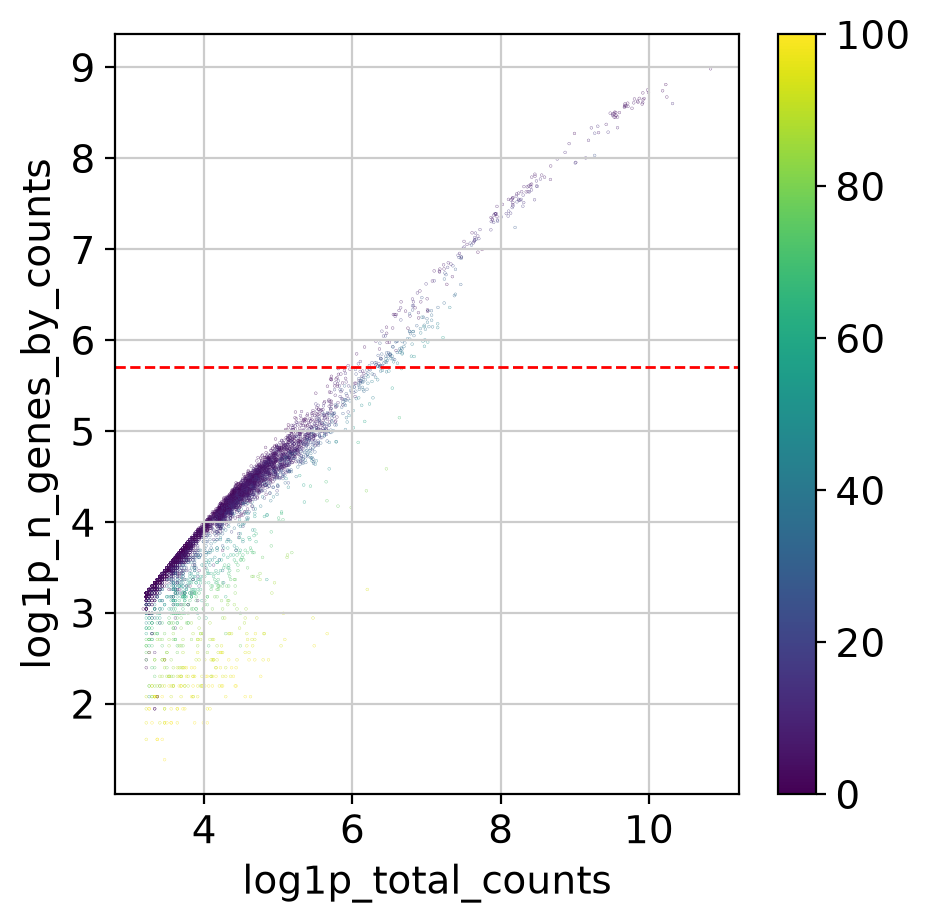

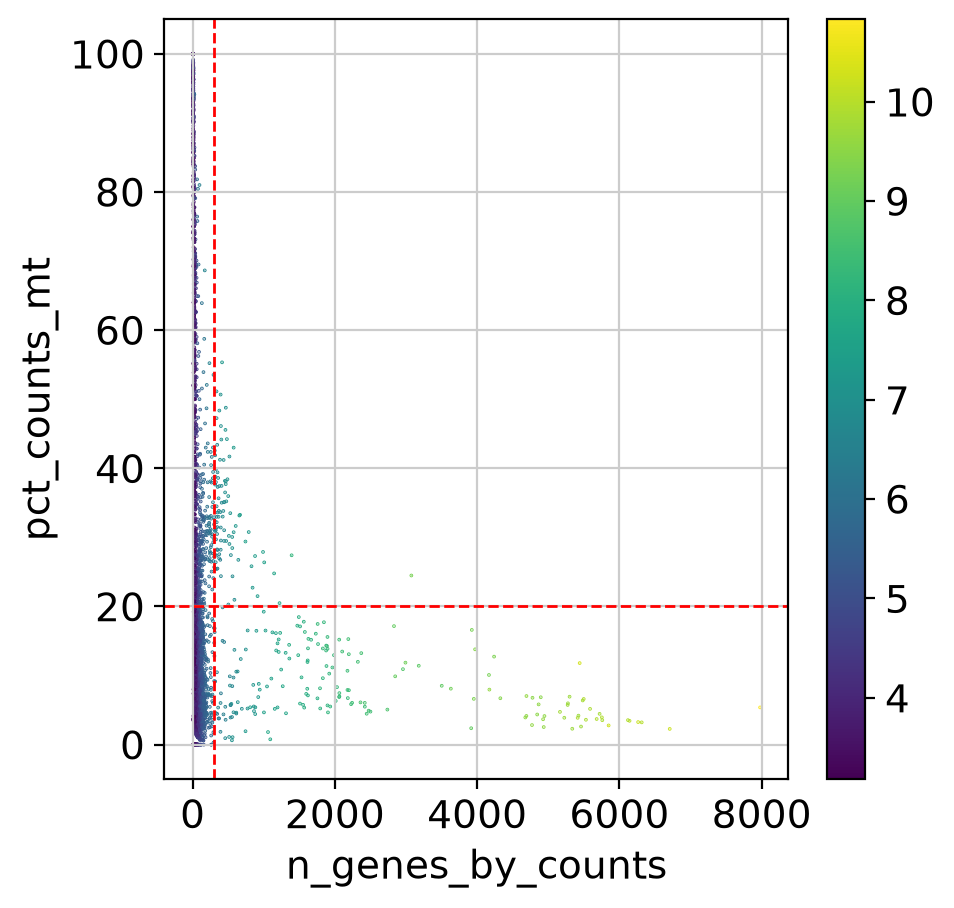

In [15]:
plt.scatter(adata.obs['log1p_total_counts'], adata.obs['log1p_n_genes_by_counts'], c=adata.obs['pct_counts_mt'], s=0.01)
#plt.axvline(x=np.log1p(750), color='r', linestyle='--', linewidth=1) # min_counts
plt.axhline(y=np.log1p(300), color='r', linestyle='--', linewidth=1) # min_genes
#plt.axhline(y=np.log1p(7000), color='r', linestyle='--', linewidth=1) # max_genes
plt.xlabel('log1p_total_counts')
plt.ylabel('log1p_n_genes_by_counts')
plt.colorbar()
plt.show()

plt.scatter(adata.obs['n_genes_by_counts'], adata.obs['pct_counts_mt'], c=adata.obs['log1p_total_counts'], s=0.1)
plt.axvline(x=300, color='r', linestyle='--', linewidth=1) # min_genes
#plt.axvline(x=7000, color='r', linestyle='--', linewidth=1) # max_genes
plt.axhline(y=20, color='r', linestyle='--', linewidth=1) # max_mt
plt.xlabel('n_genes_by_counts')
plt.ylabel('pct_counts_mt')
plt.colorbar()
plt.show()

In [16]:
# doublet detection

scrub = scr.Scrublet(adata.X)
scores, predicted = scrub.scrub_doublets(verbose=False)

adata.obs["doublet_scores"] = scores
adata.obs["predicted_doublets"] = predicted

print(adata.obs["predicted_doublets"].value_counts())

predicted_doublets
False    5999
True        1
Name: count, dtype: int64


In [ ]:
#sc.pp.filter_cells(adata, min_counts=500) 
#sc.pp.filter_cells(adata, min_genes=300)
#sc.pp.filter_cells(adata, max_genes=7000) 
adata = adata[adata.obs['pct_counts_mt'] < 20, :] # 20% 이상의 mitochondria 분율을 가진 Sample 제외 (doublet 일 수 있음)

In [ ]:
adata = adata[~adata.obs["predicted_doublets"]].copy()

In [ ]:
adata

# data that went through qc filtering already ; no additional filtering needed

In [17]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 2. Preprocess

In [18]:
adata.layers['counts'] = adata.X.copy()

In [19]:
print(adata.layers['counts'].max())
print(adata.layers['counts'].min())

1674.0
0.0


In [20]:
# normalization

print('before log1p norm')
print('max: ', np.max(adata.X))
print('min: ', np.min(adata.X))
print('mean: ', np.mean(adata.X))

adata.var_names_make_unique()
adata.obs_names_make_unique()

# Normalization : Sample 에서 세포 합이 모두 100,00 이 되도록 함 (Sample 간의 비교를 위해)
sc.pp.normalize_total(adata, target_sum=1e4)

# Matrix 가 잘 정규화 되었는지 확인
adata.X.sum(axis=1)

# Logarithmize
sc.pp.log1p(adata)
adata.raw = adata
print('after log1p norm')
print('max: ', np.max(adata.X))
print('min: ', np.min(adata.X))
print('mean: ', np.mean(adata.X))

before log1p norm
max:  1674.0
min:  0.0
mean:  0.008874481
normalizing counts per cell
    finished (0:00:00)
after log1p norm
max:  8.859084
min:  0.0
mean:  0.011985781


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


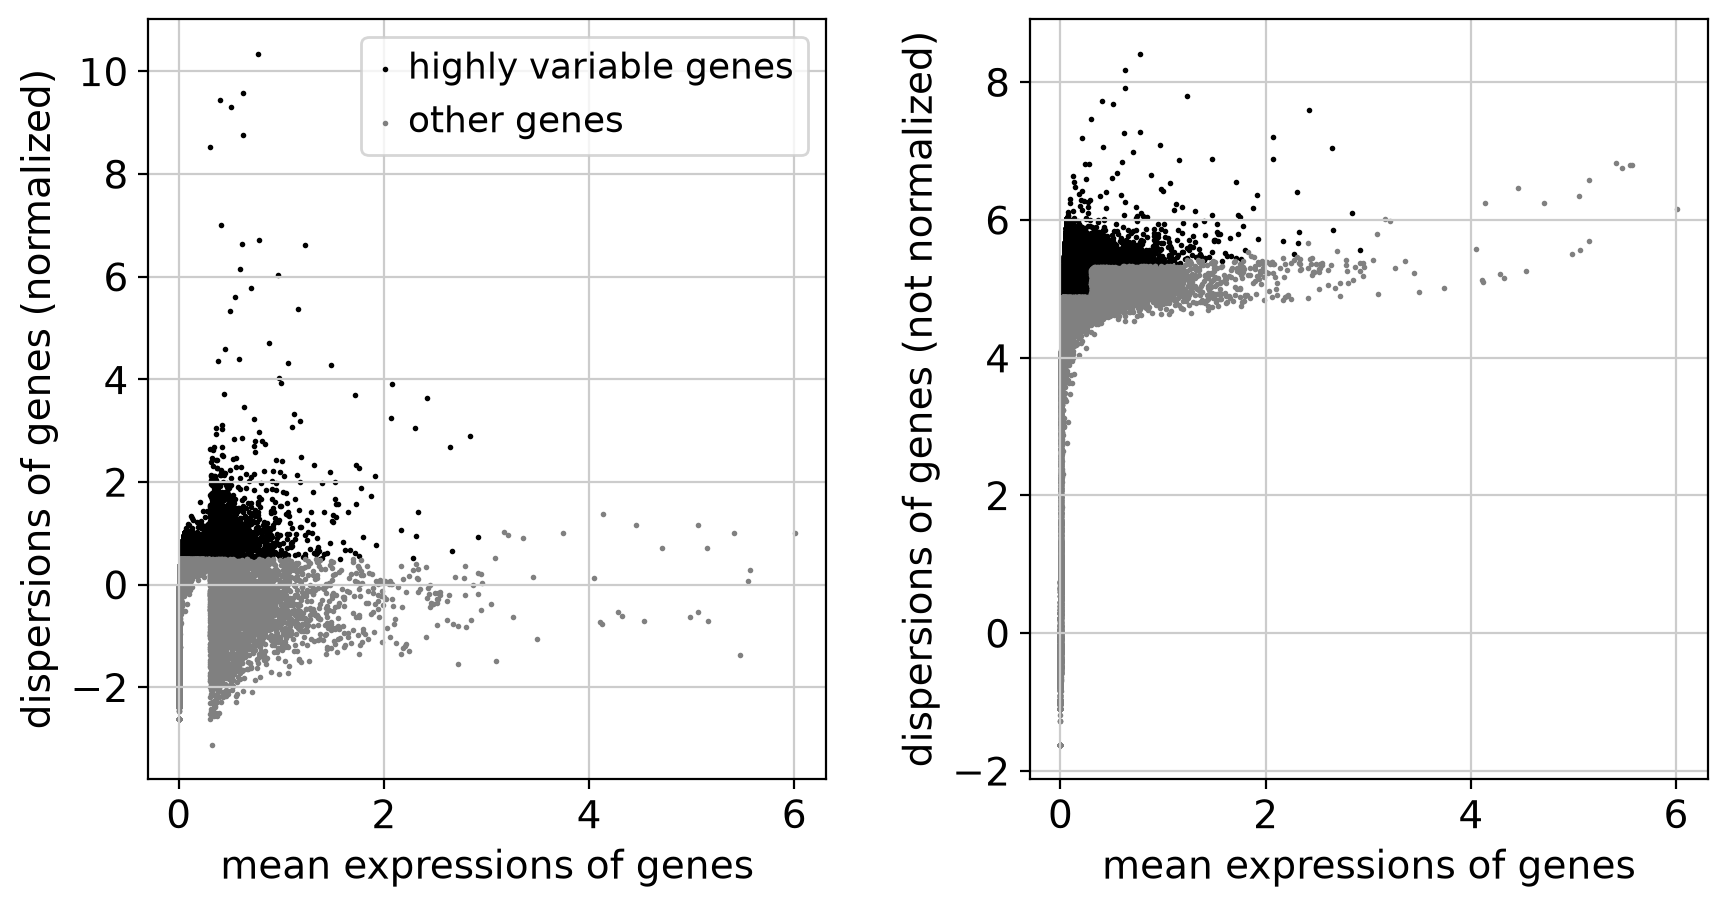

detected 8510 highly variable genes


In [21]:
# HVG (Highly variable genes) : adata 에서 어떤 Gene 들이 많이 차이가 나는지 확인
sc.pp.highly_variable_genes(adata) # adata 에서 HVG 에 해당하는 Gene 갯수를 확인
sc.pl.highly_variable_genes(adata)
print(f"detected {np.sum(adata.var['highly_variable'])} highly variable genes")

sc.pp.scale(adata, max_value=10)

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 3. Feature Selecetion

computing PCA
    with n_comps=50
    finished (0:00:02)


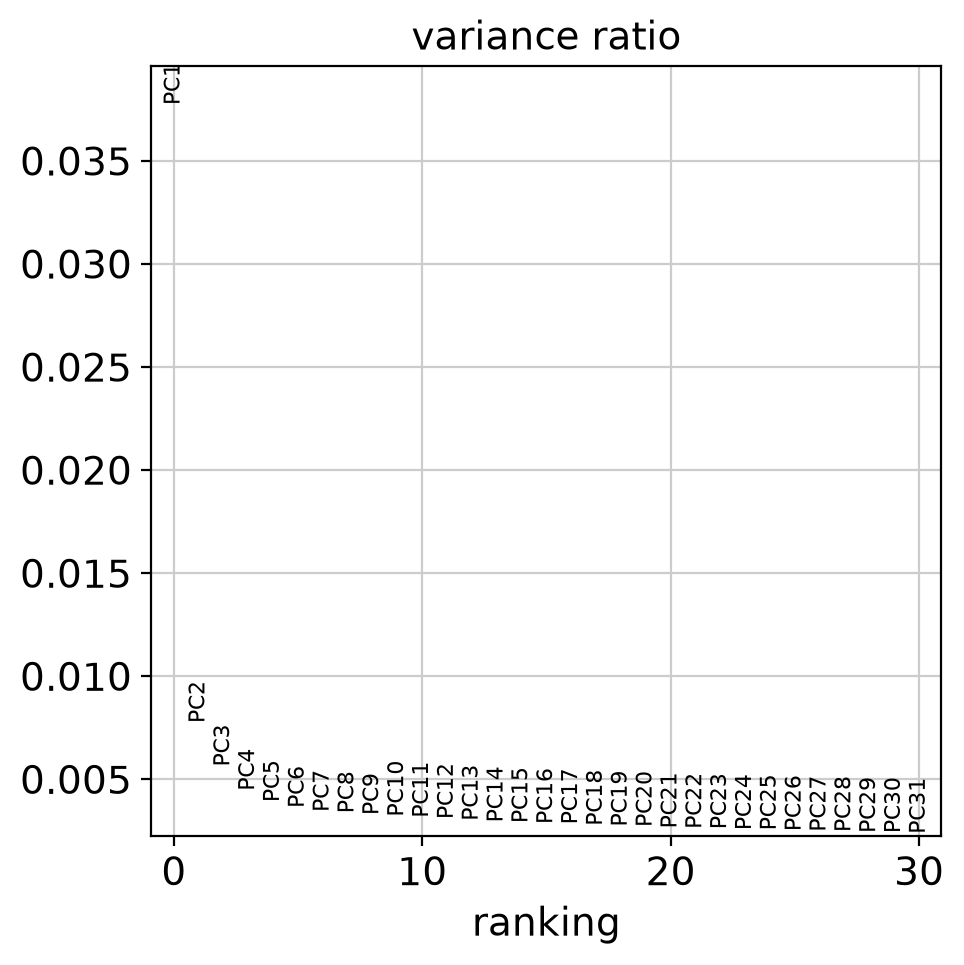

In [22]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)

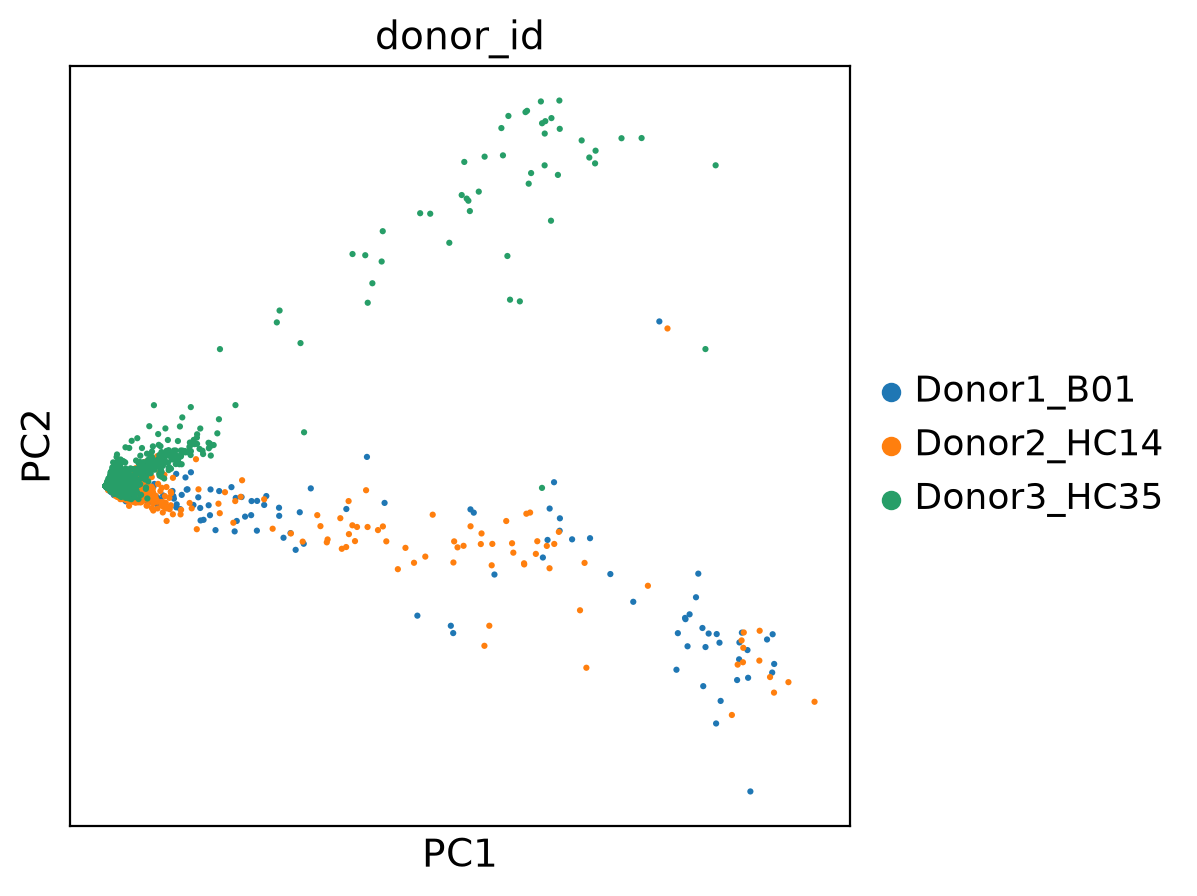

In [23]:
sc.pl.pca(adata, color = 'donor_id')

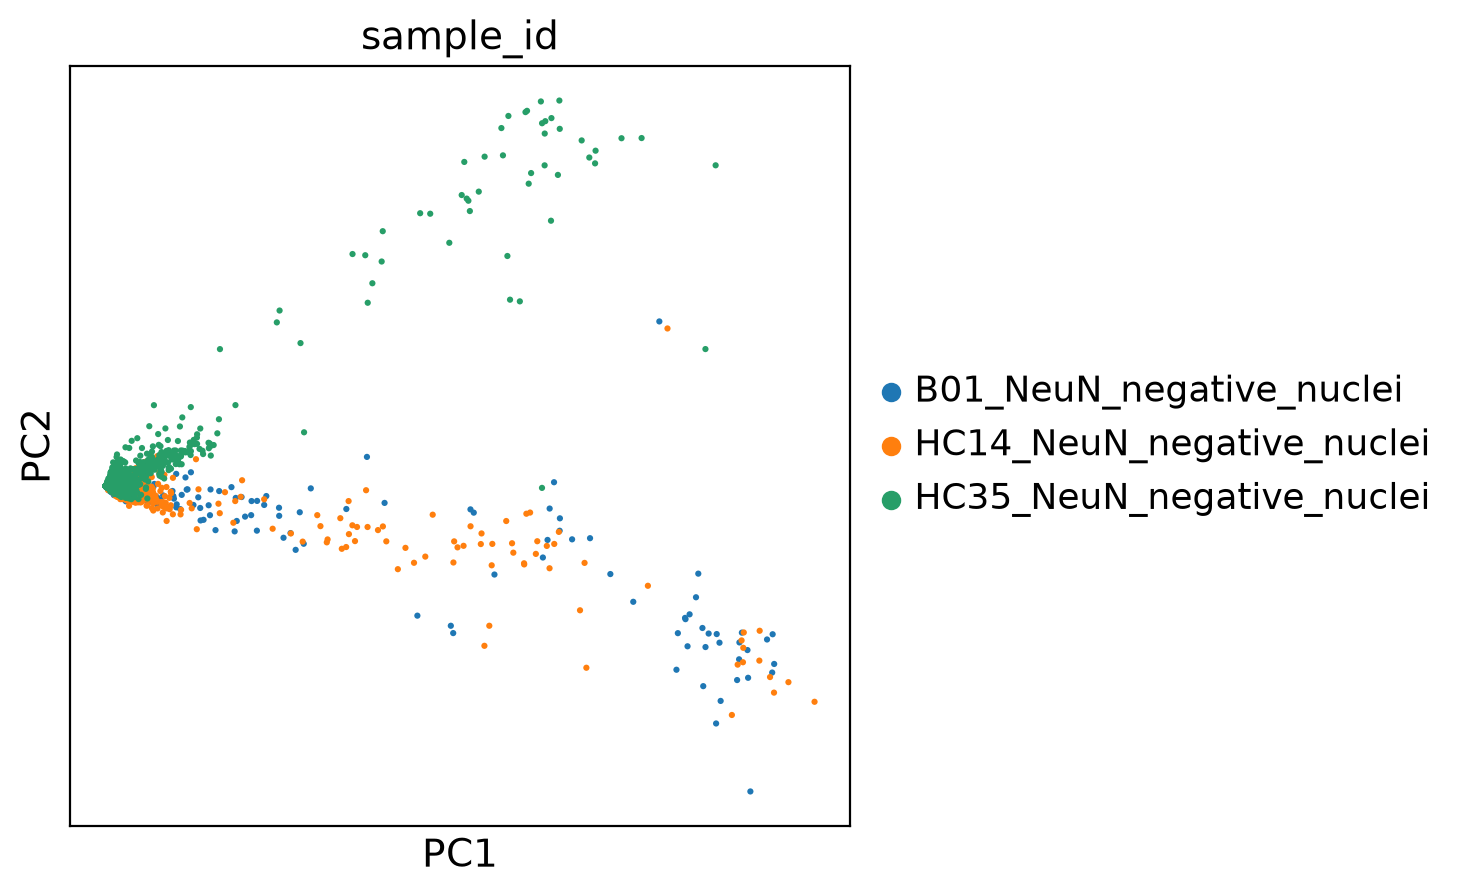

In [24]:
sc.pl.pca(adata, color = 'sample_id')

computing neighbors


/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


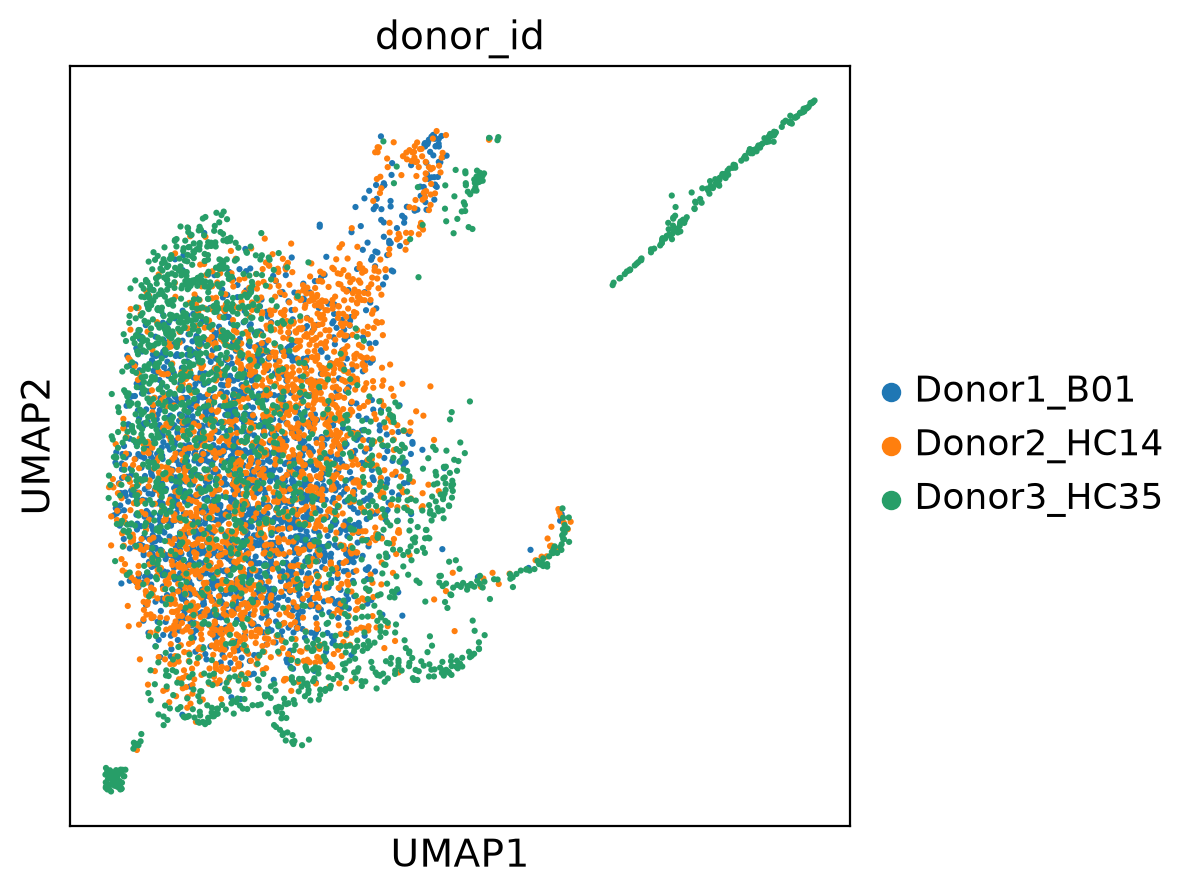

In [25]:
# without batch correction

sc.pp.neighbors(adata, use_rep = 'X_pca', n_pcs = 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color = 'donor_id', save=f"_{TODAY}_{dataset}_donor_xharmony_npcs=20.png")

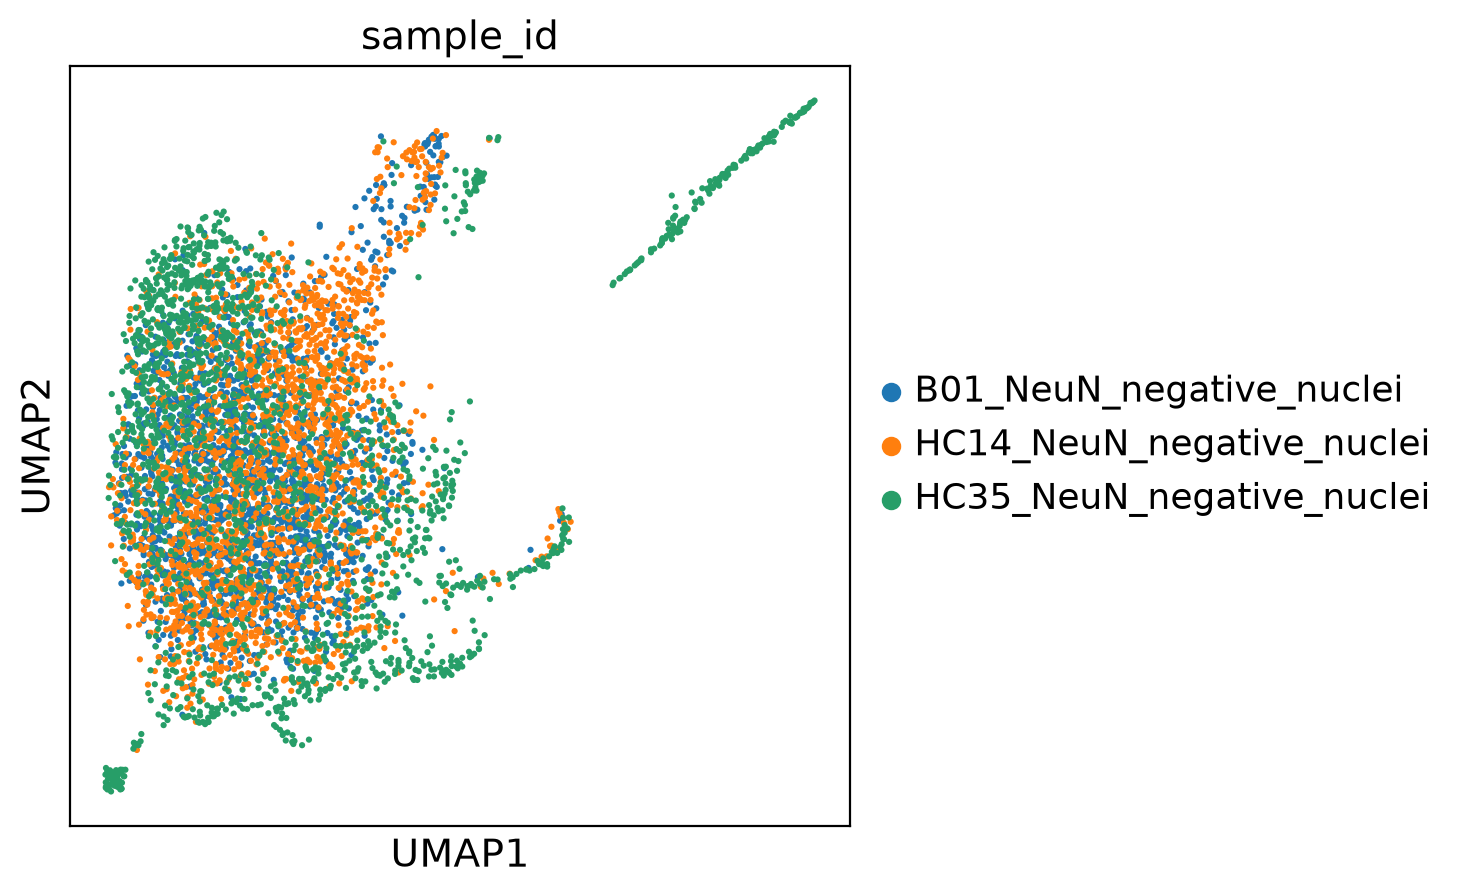

In [26]:
sc.pl.umap(adata, color = 'sample_id', save=f"_{TODAY}_{dataset}_sample_xharmony_npcs=20.png")

In [27]:
import harmonypy as hm

ho = hm.run_harmony(
    adata.obsm["X_pca"].astype(np.float64),
    adata.obs,
    "sample_id",
    max_iter_harmony=50
)

print(ho.Z_corr.shape)
adata.obsm["X_pca_harmony"] = np.asarray(ho.Z_corr)

2026-09-13 02:36:11,711 - harmonypy - INFO - Running Harmony
2026-09-13 02:36:11,712 - harmonypy - INFO -   Parameters:
2026-09-13 02:36:11,713 - harmonypy - INFO -     max_iter_harmony: 50
2026-09-13 02:36:11,713 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-13 02:36:11,714 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-13 02:36:11,714 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-13 02:36:11,715 - harmonypy - INFO -     nclust: 100
2026-09-13 02:36:11,716 - harmonypy - INFO -     block_size: 0.05
2026-09-13 02:36:11,716 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-13 02:36:11,717 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-09-13 02:36:11,718 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-13 02:36:11,719 - harmonypy - INFO -     verbose: True
2026-09-13 02:36:11,719 - harmonypy - INFO -     random_state: 0
2026-09-13 02:36:11,720 - harmonypy - INFO -   Data: 50 PCs × 6000 cells
2026-09-13 02:36:11,720 - harmonypy - INFO -   B

(6000, 50)


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


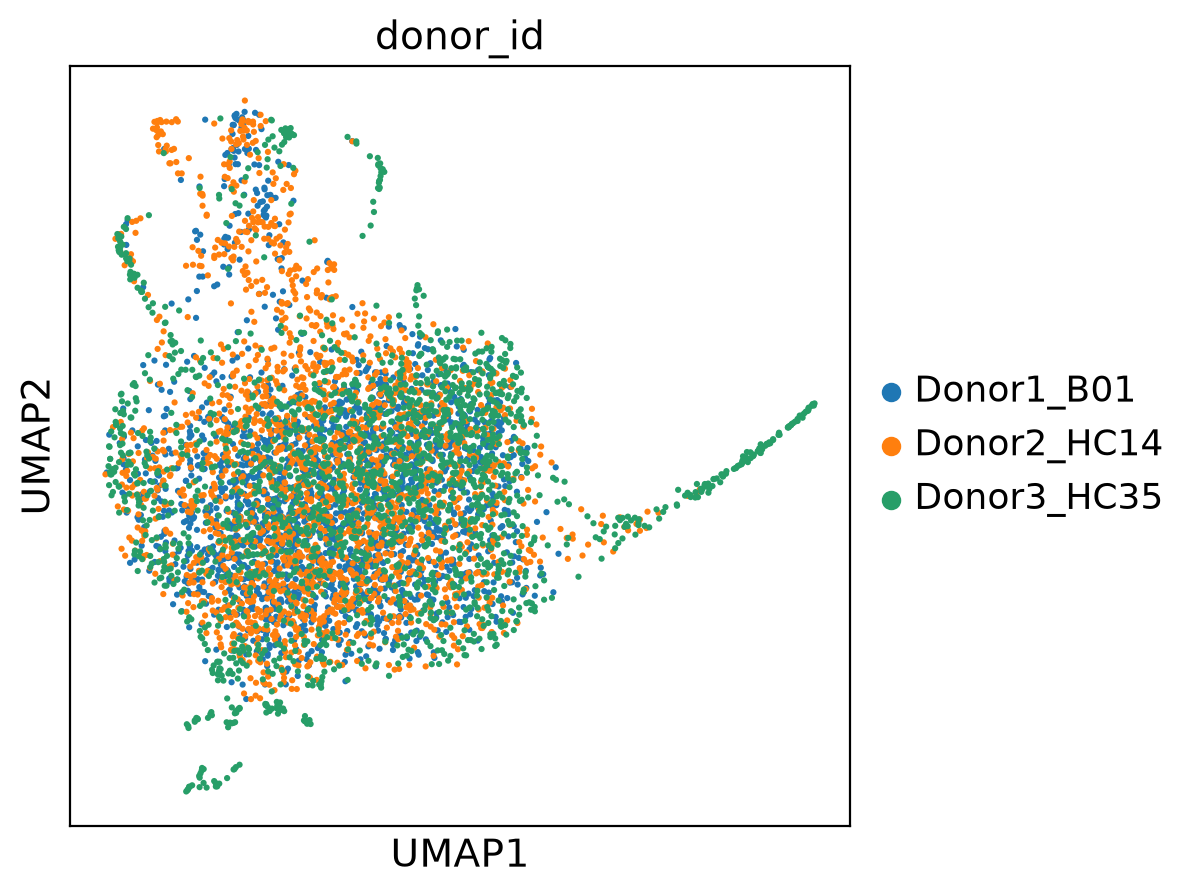

In [28]:
# with batch correction

sc.pp.neighbors(adata, use_rep = 'X_pca_harmony', n_pcs = 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color = 'donor_id', save=f"_{TODAY}_{dataset}_donor_harmony_npcs=20.png")

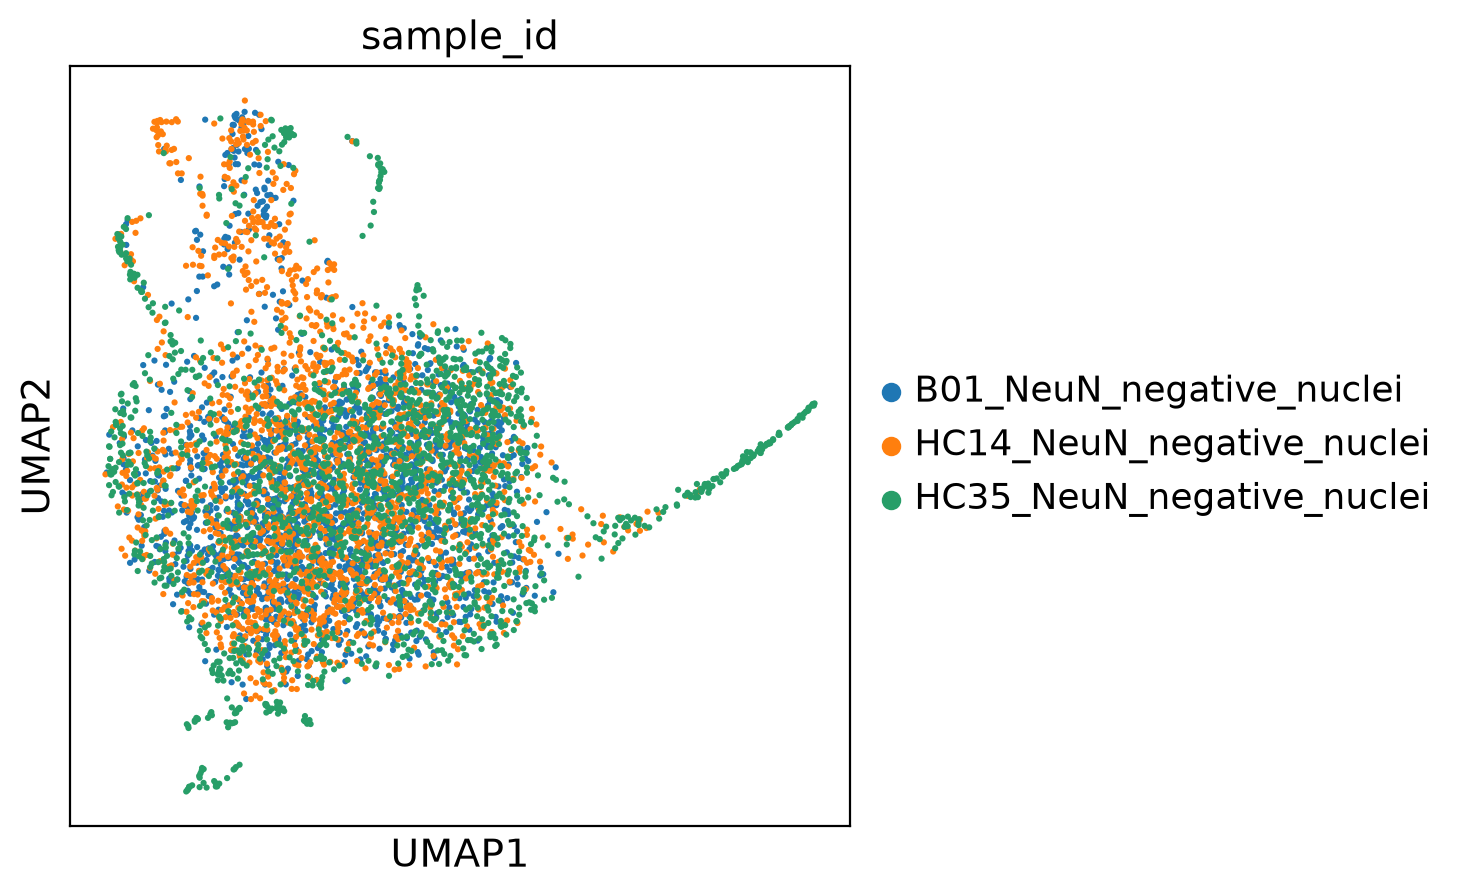

In [29]:
sc.pl.umap(adata, color = 'sample_id', save=f"_{TODAY}_{dataset}_sample_harmony_npcs=20.png")

# 4. Clustering

In [30]:
sc.tl.leiden(adata, resolution = 0.5, key_added='leiden_05')
sc.tl.leiden(adata, resolution = 1.0, key_added='leiden_10')

running Leiden clustering


/tmp/ipykernel_3445545/4008177221.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5, key_added='leiden_05')


    finished: found 10 clusters and added
    'leiden_05', the cluster labels (adata.obs, categorical) (0:00:06)
running Leiden clustering
    finished: found 16 clusters and added
    'leiden_10', the cluster labels (adata.obs, categorical) (0:00:18)


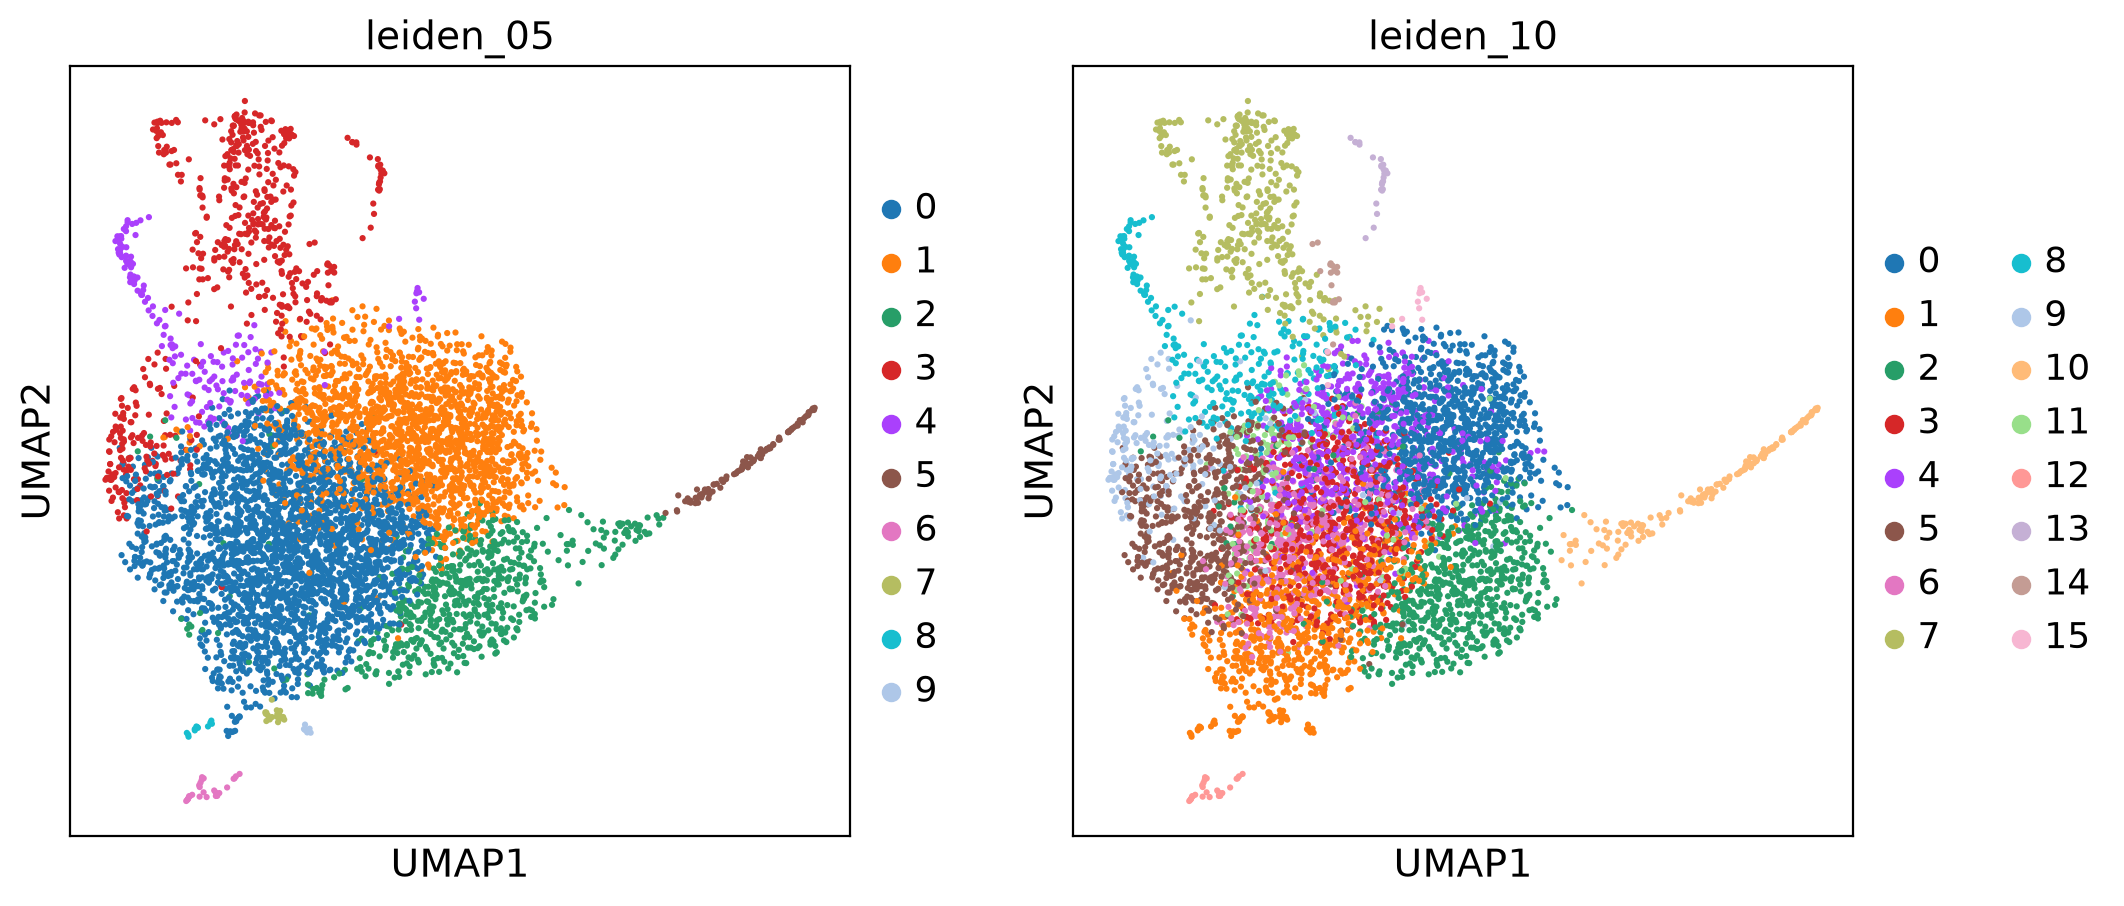

In [31]:
scl.us(adata, 'leiden_05,leiden_10')

In [32]:
sc.tl.rank_genes_groups(adata, groupby='leiden_05', method='wilcoxon', use_raw=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:15)


/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

In [ ]:
adata.var_names = adata.var['gene_symbols'].copy()
adata.var_names_make_unique()

print(adata.var_names[:10])
print(adata.var_names.is_unique)

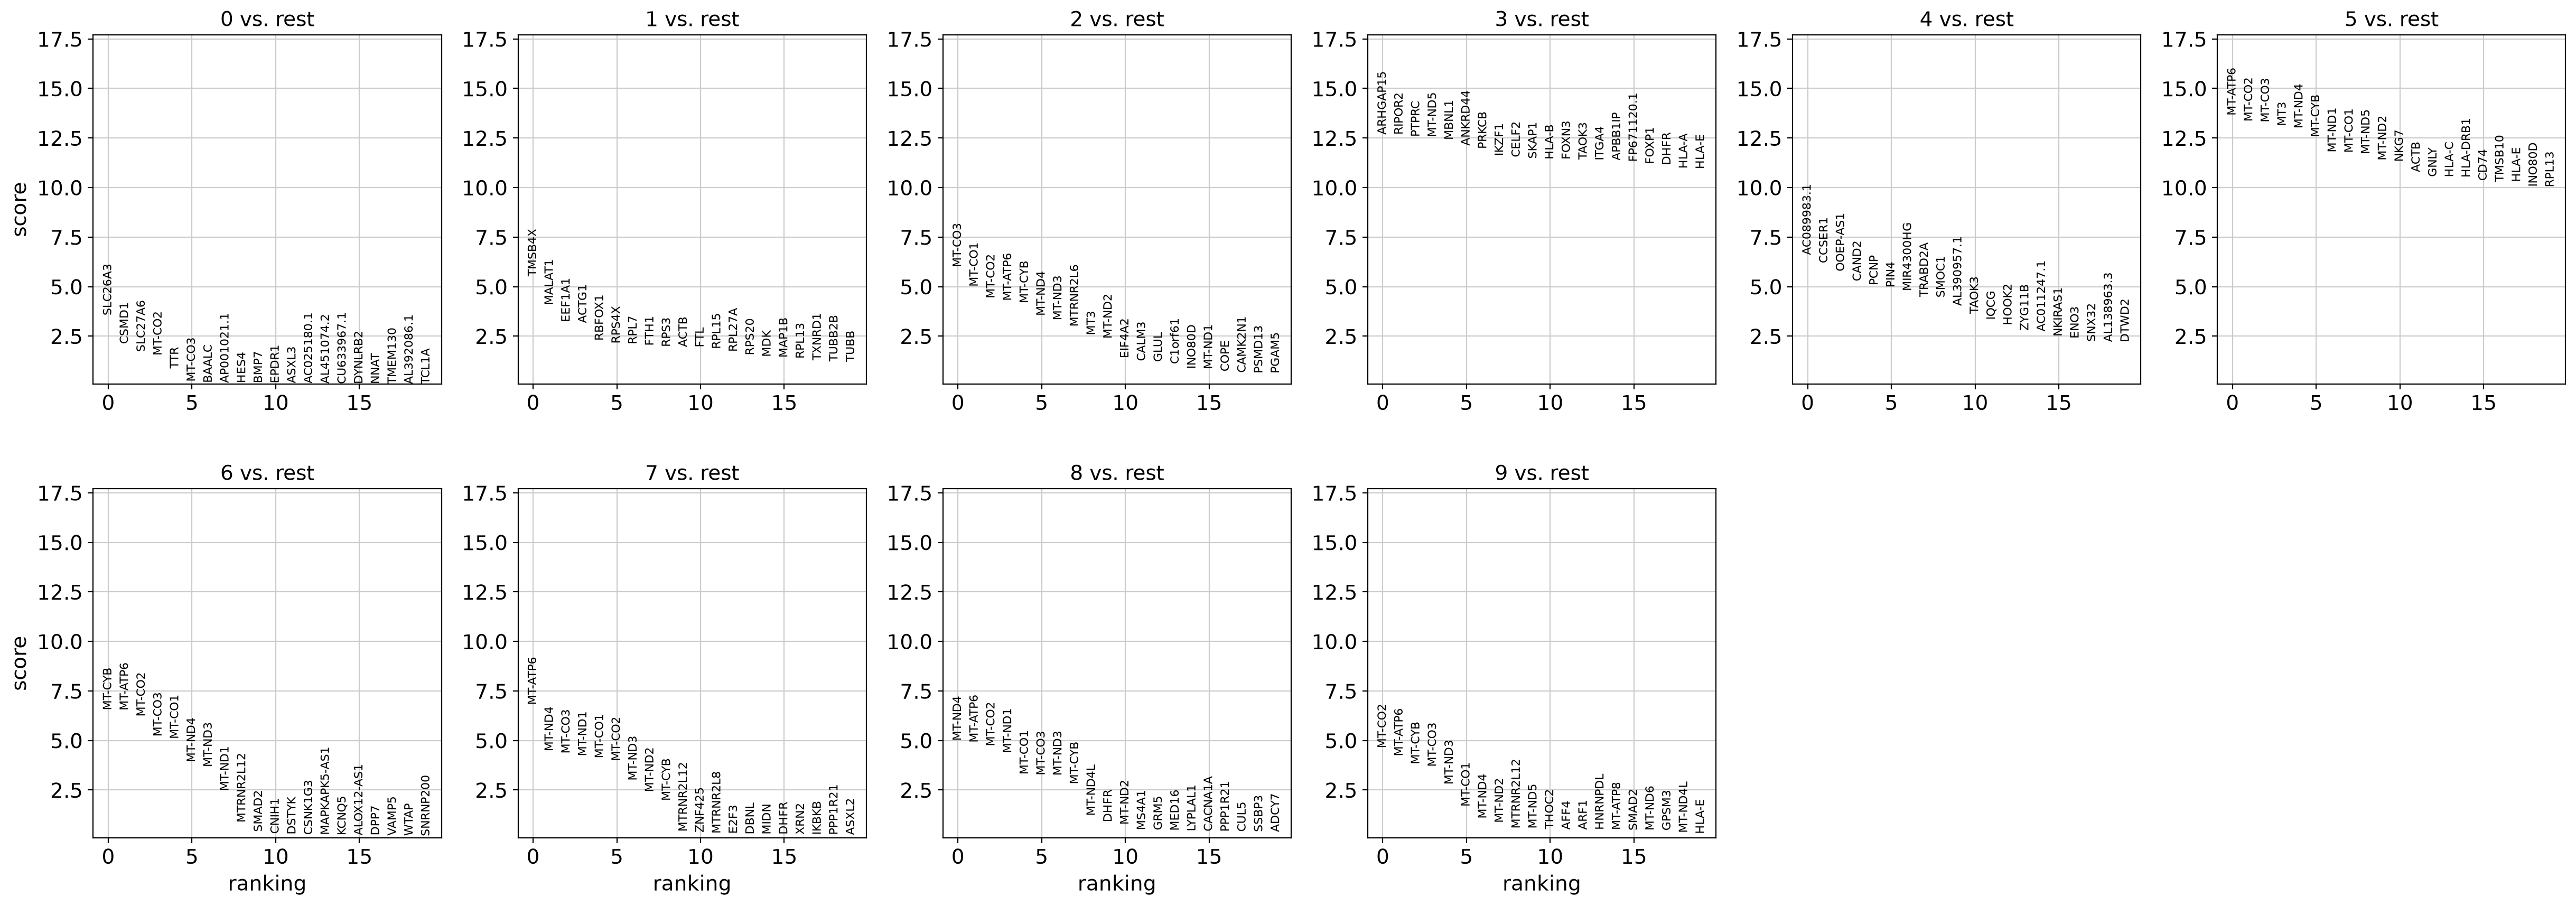

In [33]:
sc.pl.rank_genes_groups(adata, ncols = 6)

In [ ]:
M = scl.markers.marker(adata,'leiden_05')
M.plot_marker()

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

## if gene names are ensg

In [ ]:
raw = adata.raw.to_adata()

raw.var_names = raw.var['gene_symbols'].astype(str)
raw.var_names_make_unique()

adata.raw = raw

In [ ]:
adata.raw.var.index.name = "feature_id"
adata.var.index.name = "feature_id"

if adata.raw is not None:
    adata.raw.var.index.name = "feature_id"

In [ ]:
gene_to_id = dict(zip(odata.var["gene_symbols"], odata.var_names))

adata.var["source_gene_id"] = adata.var["gene_symbols"].map(gene_to_id)

print(adata.var[["gene_symbols", "source_gene_id"]].head())
print("Unmapped:", adata.var["source_gene_id"].isna().sum())

# 5. Lv.1 Annotation

In [34]:
markers_full = {
    "Microglia": [
        "P2RY12", "P2RY13", "TMEM119", "CX3CR1",
        "C1QA", "C1QB", "C1QC", "GPR34", "CSF1R"
    ],
    "Macrophage_MDM": [
        "FCGR3A", "LILRB1", "LILRB2", "CTSD",
        "CTSB", "LGALS3", "APOE", "SPP1"
    ],
    "Lymphocyte": [
        "CD3D", "CD3E", "TRBC1", "TRBC2",
        "SKAP1", "CD96", "CCL4", "NKG7"
    ],
    "Astrocyte": [
        "AQP4", "SLC1A2", "SLC1A3", "GFAP", "ALDH1L1"
    ],
    "Oligodendrocyte": [
        "PLP1", "MBP", "MOG", "MAG", "MOBP"
    ],
    "OPC": [
        "PDGFRA", "CSPG4", "VCAN", "OLIG1", "OLIG2"
    ],
    "Endothelial": [
        "CLDN5", "FLT1", "PECAM1", "VWF", "EMCN"
    ],
    "Pericyte": [
        "RGS5", "ABCC9", "PDGFRB", "CSPG4", "MCAM"
    ],
    "Neuron" : [
    'SNAP25', 'SYT1', 'RBFOX1',
    'STMN2', 'NEFL', 'NEFM',
    'MAP2', 'TUBB3',
    'GRIN1', 'DLG4'
    ],
}

gene_set = set(adata.var_names.dropna())

markers = {
    celltype: [gene for gene in genes if gene in gene_set]
    for celltype, genes in markers_full.items()
}

In [35]:
umap_markers = [
    # Microglia
    "P2RY12", "TMEM119", "C1QA",

    # Macrophage / MDM
    "FCGR3A", "LGALS3", "SPP1",

    # Lymphocyte
    "CD3D", "NKG7",

    # Astrocyte
    "AQP4", "SLC1A2",

    # Oligodendrocyte
    "MOG", "MOBP",

    # OPC
    "PDGFRA", "VCAN",

    # Endothelial
    "CLDN5", "VWF",

    # Pericyte
    "RGS5", "PDGFRB",

    # Neuron
    'SNAP25', 'SYT1', 'RBFOX1',
]

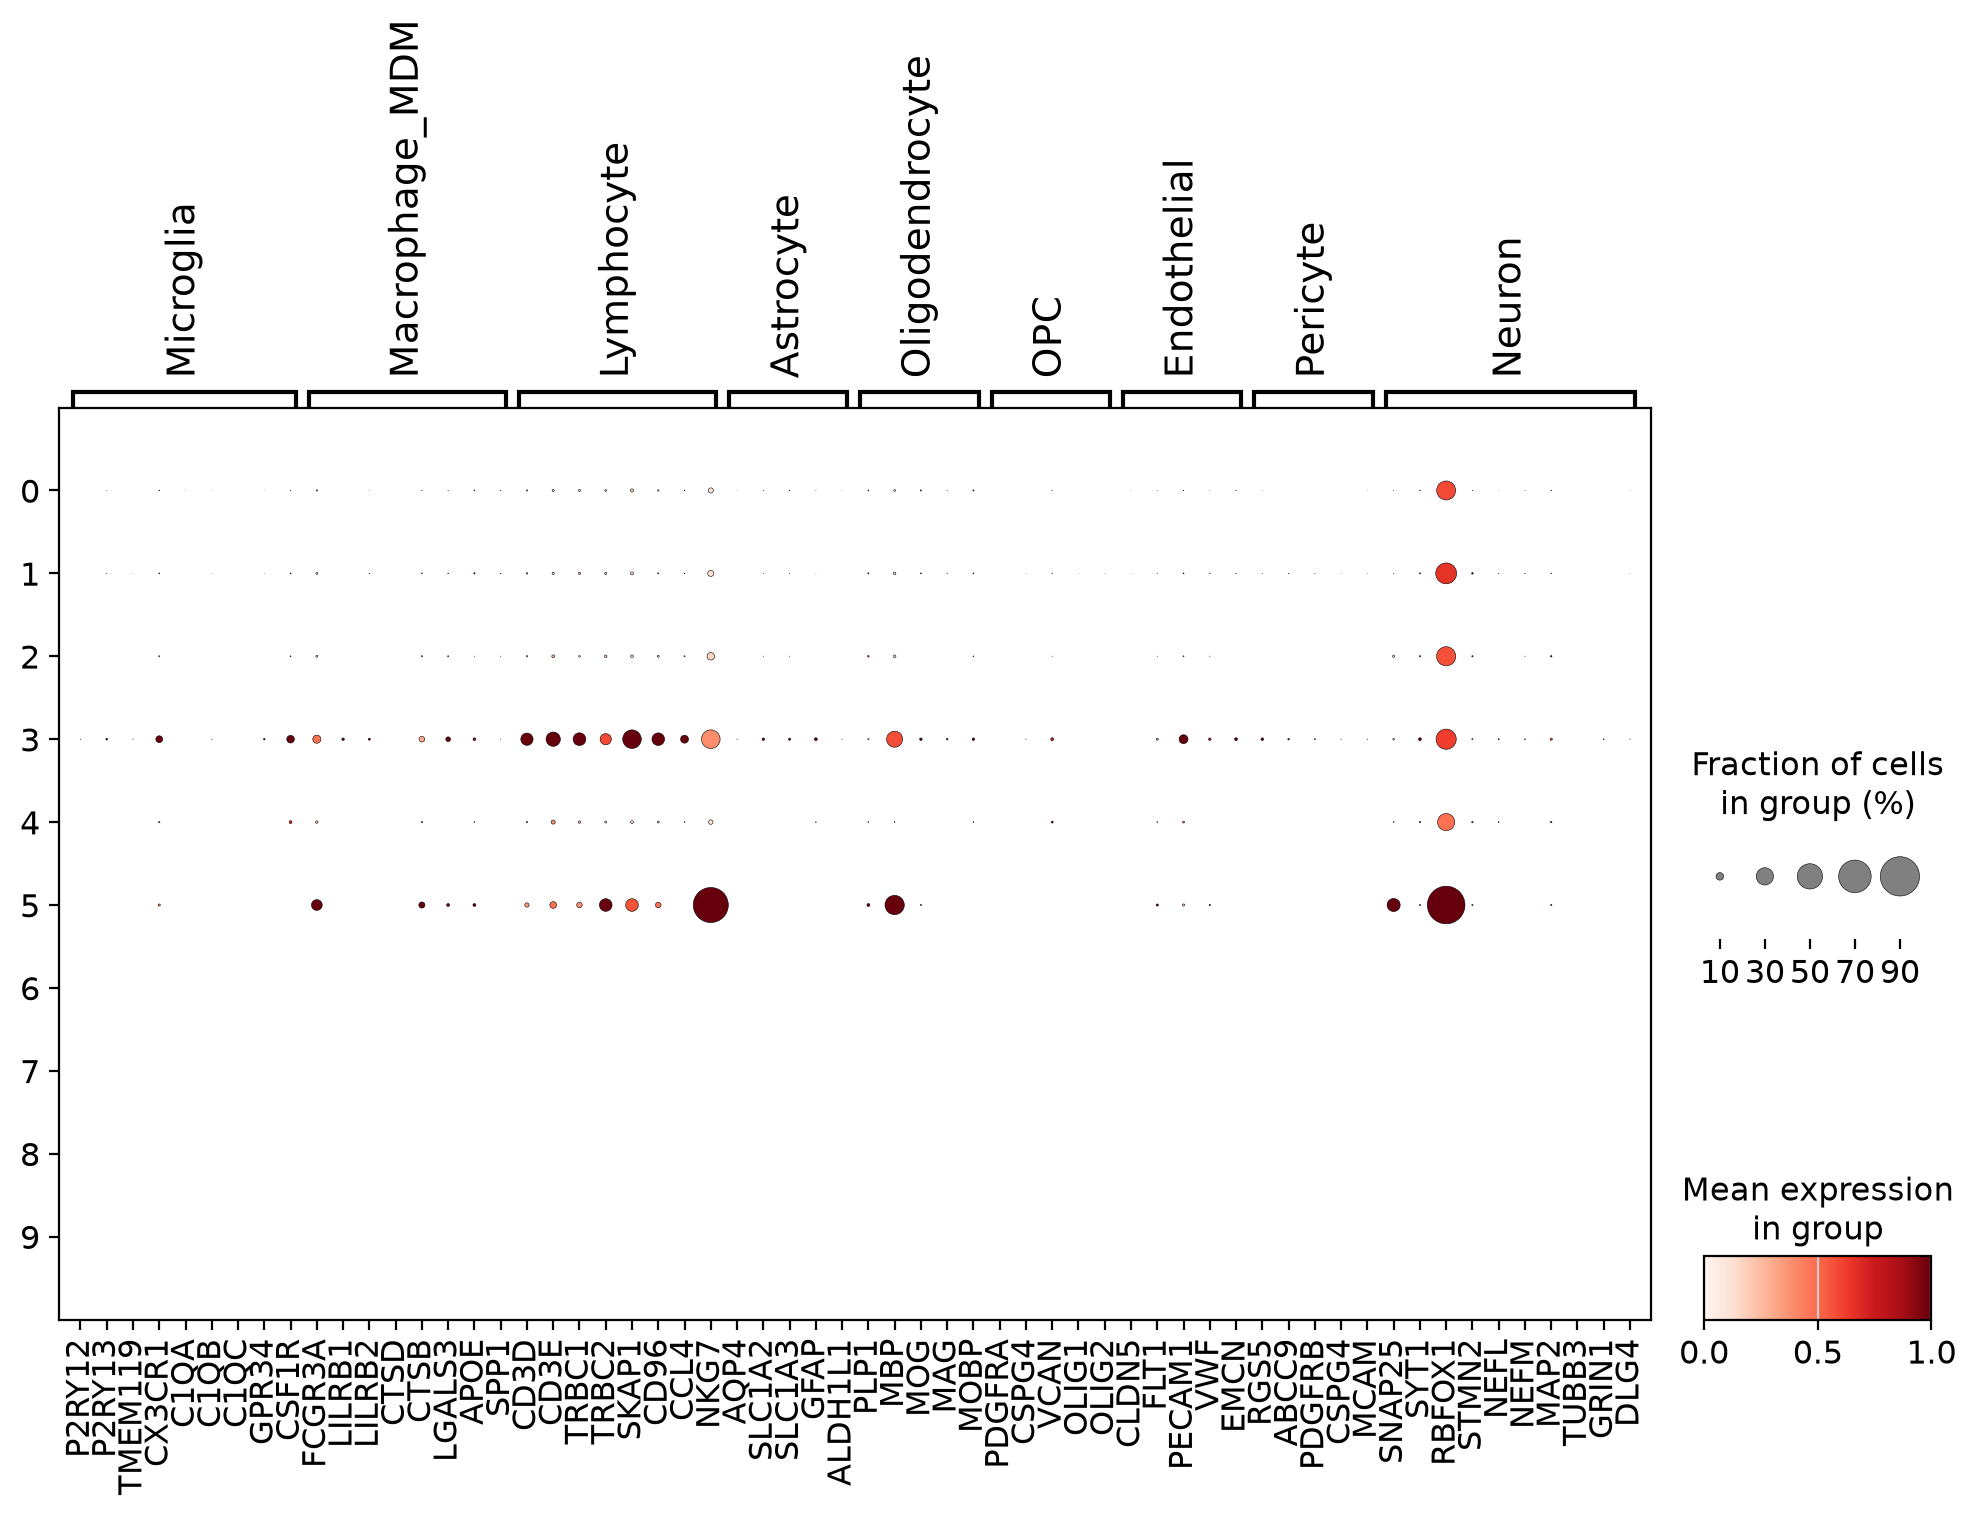

In [36]:
sc.pl.dotplot(
    adata,
    markers,
    groupby="leiden_05",
    standard_scale="var",
    dendrogram=False,
    figsize=(max(12, len(markers) * 0.35), 6),
)

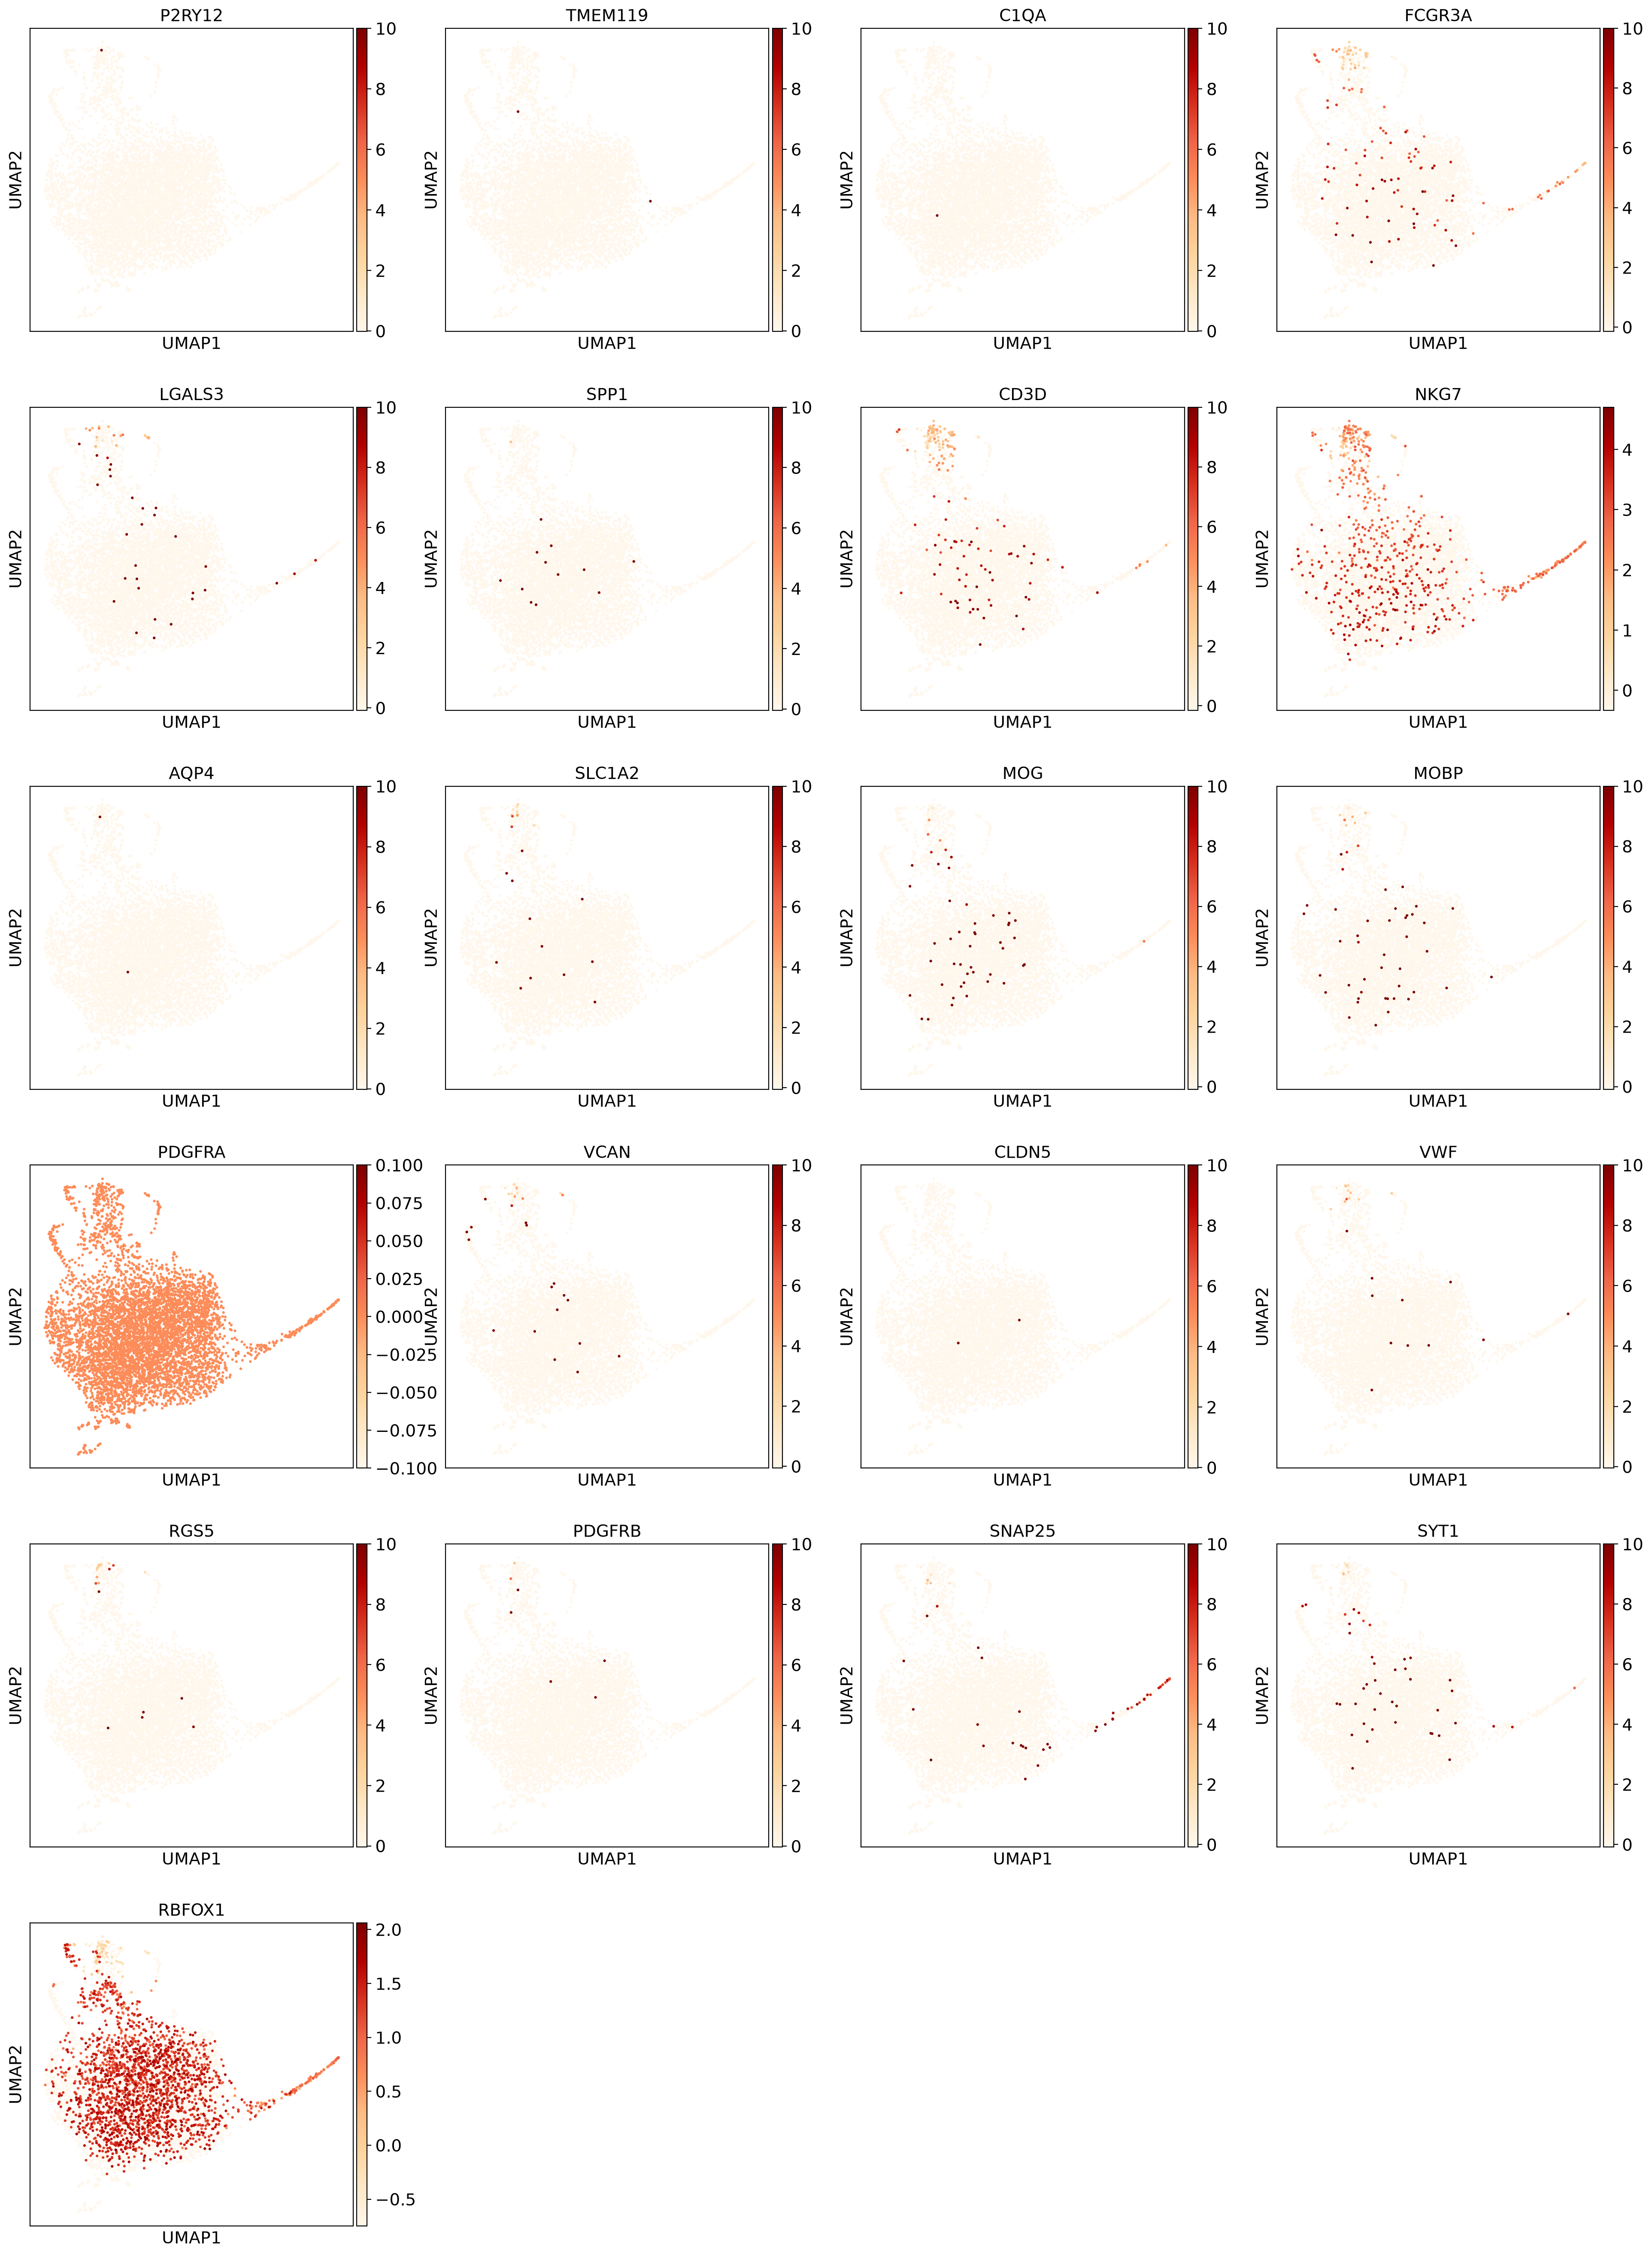

In [37]:
scl.us(adata, umap_markers)

In [ ]:
lv1_map = {
    "0": "Oligodendrocyte",
    "1": "Microglia",
    "2": "OPC",
    "3": "Neuron",
    "4": "Neuron",
    "5": "Oligodendrocyte",
    "6": "Neuron",
    "7": "Astrocyte",
    "8": "Neuron",
    "9": "Neuron",
    "10": "Neuron",
    "11": "Endothelial",
    "12": "Doublet"
}

adata.obs["celltype_lv1"] = (
    adata.obs["leiden_05"]
    .astype(str)
    .map(lv1_map)
    .astype("category")
)

In [ ]:
scl.us(adata, 'leiden_05,celltype_lv1')

In [38]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 6. Microglia Lv. 2 annotation

In [ ]:
print(adata)

mdata = adata[
    adata.obs["celltype_lv1"].isin(["Microglia"])
].copy()

In [ ]:
mdata

In [ ]:
mdata.X = mdata.layers['counts'].copy()
print(mdata.X.max(), mdata.X.min())

In [ ]:
# preprocess
sc.pp.normalize_total(mdata)
sc.pp.log1p(mdata)
sc.pp.highly_variable_genes(mdata)
sc.pp.scale(mdata)

In [ ]:
# feature selection
sc.tl.pca(mdata)
sc.pl.pca_variance_ratio(mdata)

In [ ]:
sc.pp.neighbors(mdata, use_rep = 'X_pca', n_pcs=20)
sc.tl.umap(mdata)
scl.us(mdata, 'donor_id,sample_id')

In [ ]:
#mdata.obs.drop(columns=["leiden_05", "leiden_10"], inplace=True)
#mdata.uns.pop("cdm_leiden_05", None)
for key in ["leiden_05", "leiden_10", "leiden_05_colors", "leiden_10_colors"]:
    mdata.uns.pop(key, None)

In [ ]:
mdata

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_mg.h5ad")